# Import Variables and Load Packages

In [2]:
import uproot
#print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle
import matplotlib as mpl

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/H-KPMTcalibration/HKPMTcalibration/LIGen395_Pos0_hits_flat.root')
print(f.keys())

print(f['photonTree'].keys())
f['hitsTree'].keys()


['photonTree;2', 'photonTree;1', 'hitsTree;2', 'hitsTree;1']
['event', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ']


['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

## Load Variables

In [28]:
photon = ['event', 
          'startX', 
          'startY', 
          'startZ', 
          'endX', 
          'endY', 
          'endZ'
        ]

hits = ['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

vars = {}
vars2 = {}
vars.update(f["photonTree"].arrays(photon, library="np"))
vars2.update(f["hitsTree"].arrays(hits, library="np"))

for key, value in vars.items():
    print(f"{key}: {len(value)}")

for key, value in vars2.items():
    print(f"{key}: {len(value)}")
    
for col in vars:
    vars[col] = vars[col].tolist()
    
for col in vars2:
    vars2[col] = vars2[col].tolist()

ph_df = pd.DataFrame(vars)
hit_df = pd.DataFrame(vars2)

event: 3404536
startX: 3404536
startY: 3404536
startZ: 3404536
endX: 3404536
endY: 3404536
endZ: 3404536
event: 3051901
subevent: 3051901
pmt_id: 3051901
charge: 3051901
time: 3051901
posX: 3051901
posY: 3051901
posZ: 3051901


In [54]:
#ph_df[ph_df["event"] == 9999]
#hit_df[hit_df["event"] == 9999]

#small_y_df = ph_df[abs(ph_df["startY"])<.0001]

moved_df = ph_df[
    (ph_df["startX"] != ph_df["endX"]) &
    (ph_df["startY"] != ph_df["endY"]) &
    (ph_df["startZ"] != ph_df["endZ"])
]

near_source_df = ph_df[ph_df["startX"]<4000]

moved_and_near_source_df = moved_df[moved_df["startX"]<4000]

print(f'number of moved photons (start x,y,z != end x,y,z): {len(moved_df)}')
print(f'number of photons near source (startX<4000): {len(near_source_df)}')
print(f'number of photons that move and have startX<4000: {len(moved_and_near_source_df)}')





number of moved photons (start x,y,z != end x,y,z): 939103
number of photons near source (startX<4000): 2465433
number of photons that move and have startX<4000: 0


# 3D Plotting

x: (-3242.76611328125, 3242.76611328125), y: (-3242.76611328125, 3242.76611328125), z: (-3296.47119140625, 3296.47119140625)


/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_7682/4027617233.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


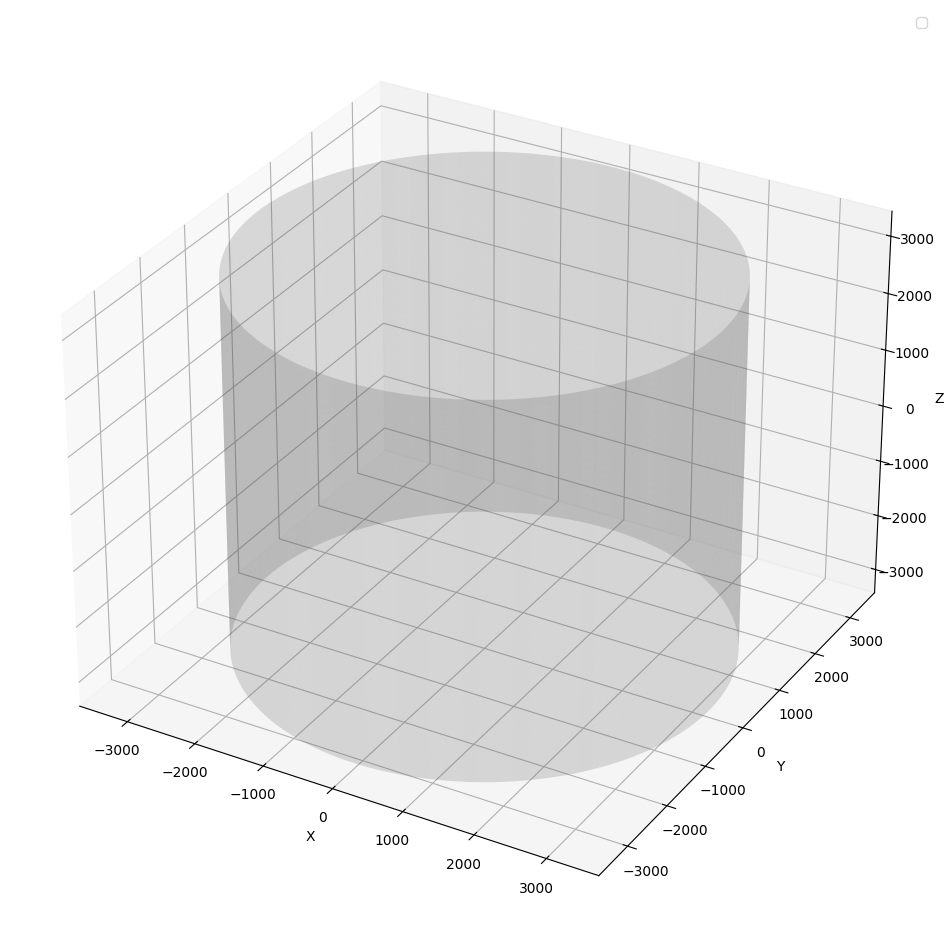

In [ ]:
# standard cylinder

ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

mpl.rcParams['agg.path.chunksize'] =  4051901

# Prepare arrays x, y, z
zs = hit_df["posZ"][:20000]
xs = hit_df["posX"][:20000]
ys = hit_df["posY"][:20000]

xmin = -3242.76611328125
xmax = 3242.76611328125
ymin = -3242.76611328125
ymax = 3242.76611328125
zmin = -3296.47119140625
zmax = 3296.47119140625

print(f'x: {xmin, xmax}, y: {ymin, ymax}, z: {zmin, zmax}')

radius = 3242.76611328125
z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
theta = np.linspace(0, 2*np.pi, 1000)
Theta, Zc = np.meshgrid(theta, z)
Xc = radius * np.cos(Theta)
Yc = radius * np.sin(Theta)

# Draw parameters
rstride = 20
cstride = 10
ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.show()

/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_1148/4114612686.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.39990234375 3106.39990234375
3106.399902343

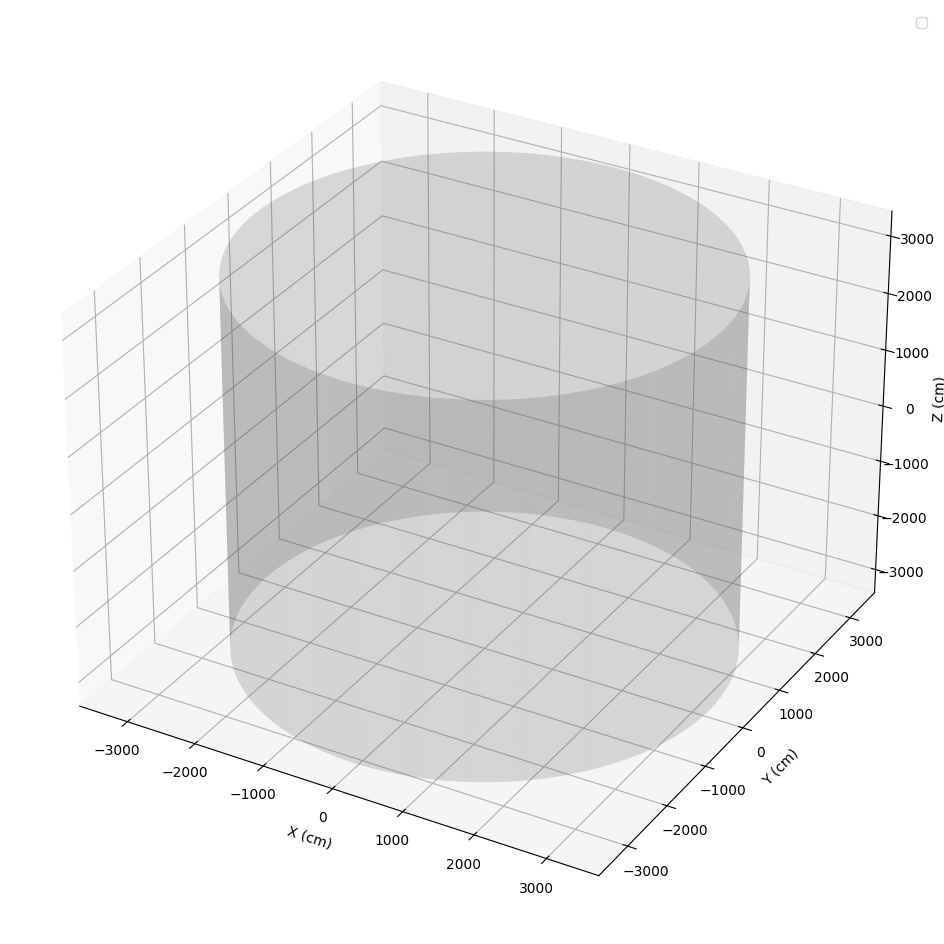

In [43]:
ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

#cylinder
radius = 3242.76611328125
z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
theta = np.linspace(0, 2*np.pi, 1000)
Theta, Zc = np.meshgrid(theta, z)
Xc = radius * np.cos(Theta)
Yc = radius * np.sin(Theta)
# cyl parameters
rstride = 20
cstride = 10
ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

# photon trajectories

event_ph_df = ph_df[ph_df["event"] == 9999]
event_hit_df = hit_df[hit_df["event"] == 9999]

x_starts = y_df["startX"]
y_starts = y_df["startY"]
z_starts = y_df["startZ"]

x_ends = y_df["endX"]
y_ends = y_df["endY"]
z_ends = y_df["endZ"]

for xs, ys, zs, xe, ye, ze in zip(x_starts, y_starts, z_starts, x_ends, y_ends, z_ends):
    ax.plot([xs, xe], [ys, ye], [zs, ze], color='blue', alpha=0.5)
    print(xs, xe)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.legend()
plt.show()